In [17]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [18]:
### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Full run mode


In [19]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_50.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_50.parquet')

df_all_feature

,MP,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,RDKit_BCUT2D_MWLOW,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,176.35,2.598909,2.474265,-2.410527,2.551776,-2.347945,6.050672,-0.143735,16.542405,9.607295,...,0,0,0,0,0,0,0.871097,1,CC(OC(=O)C1=C(C(=O)O)[C@@H]2c3c([C@H]1c1c2cccc...,Train
1,142.75,2.811399,2.563039,-2.598944,2.643377,-2.527336,5.157235,-0.115961,16.265987,9.449937,...,0,0,0,0,0,0,0.642195,1,OC1CCC2(C(C1)CCC1C2CCC2(C1CC=C2)C)C,Train
2,53.50,2.303941,2.010064,-2.023241,2.095369,-1.975851,7.808871,1.619964,32.092032,10.052692,...,0,0,0,0,0,0,0.525822,1,S=C(c1ccccc1)c1ccccc1,Train
3,37.00,1.880908,1.988686,-1.972491,2.158668,-1.851426,6.326063,0.111799,35.495691,10.121175,...,0,0,0,0,0,0,0.568300,1,O=Cc1c(C)cccc1Cl,Train
4,63.00,2.629351,2.055521,-1.968631,2.278513,-1.822786,6.086527,1.296568,14.946362,10.151961,...,0,0,0,0,0,0,0.552116,1,C=Cn1c2ccccc2c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,259.00,2.036434,2.009981,-2.005682,2.084171,-2.054924,5.906948,-0.113739,16.365564,10.183003,...,0,0,0,0,0,0,0.719503,1,CC(=O)Nc1ccc(cc1)C(=O)O,Test
17216,136.50,2.420365,2.037140,-2.061273,2.027504,-2.197307,5.664699,0.137526,16.551536,10.290927,...,0,0,0,0,0,0,0.827752,1,CNC(=O)OCc1cccc(n1)COC(=O)NC,Test
17217,145.00,2.307286,2.031651,-2.011597,2.215839,-1.849125,6.300945,1.300804,35.495696,10.070486,...,0,0,0,0,0,0,0.683494,1,N#Cc1cc(cnc1Cl)c1ccccc1,Test
17218,100.00,2.457469,2.022960,-2.063343,2.146947,-1.976233,5.953861,0.098787,16.476954,10.100015,...,0,0,0,0,0,0,0.741714,1,CCC(=O)c1ccc(cc1)OCc1ccccc1,Test


In [20]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(8610, 221)


,MP,RDKit_AvgIpc,RDKit_BCUT2D_CHGHI,RDKit_BCUT2D_CHGLO,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_LOGPLOW,RDKit_BCUT2D_MRHI,RDKit_BCUT2D_MRLOW,RDKit_BCUT2D_MWHI,RDKit_BCUT2D_MWLOW,...,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5
count,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,...,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000,8610.000000
mean,126.439533,2.347412,2.171616,-2.105071,2.241283,-2.122062,6.518769,0.193649,27.908755,10.118557,...,0.011847,0.005575,0.002904,0.016957,0.000813,0.017886,0.397329,0.019861,0.586350,0.978746
std,70.732031,0.430498,0.213835,0.182013,0.189958,0.249442,1.486606,0.534188,21.575374,1.279304,...,0.110328,0.084680,0.053810,0.130905,0.035736,0.141037,2.279712,0.142005,0.164891,0.144239
min,0.000000,0.721928,1.000000,-3.029186,0.388647,-4.233698,2.151257,-1.922159,12.736876,8.893933,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034615,0.000000
25%,69.000000,2.038302,2.025195,-2.199136,2.136198,-2.300059,5.757364,-0.137944,16.356460,9.991638,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.487409,1.000000
50%,121.000000,2.303941,2.133437,-2.064467,2.234783,-2.093618,5.990086,0.069364,16.628293,10.121133,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.598458,1.000000
75%,177.000000,2.632065,2.293356,-1.988902,2.335603,-1.935667,6.655689,0.415102,32.447672,10.222899,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.703969,1.000000
max,492.500000,3.948782,3.066522,-1.000000,3.004000,-0.114300,15.020000,13.020000,127.904000,125.904000,...,2.000000,4.000000,1.000000,2.000000,2.000000,3.000000,41.000000,2.000000,0.945893,1.000000


In [22]:
def feature_engineering_workflow(data_type):
    tolerance = 0.01

    all_feature_cols = data_with_features_train.drop(
        columns=['SMILES', 'MP', 'Type', 'Ro5'], axis=1
    ).columns.tolist()

    if data_type == 'Ro5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 1].reset_index(drop=True)
    elif data_type == 'bRo5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 0].reset_index(drop=True)
    else:
        raise ValueError("data_type must be 'Ro5' or 'bRo5'")

    df_X_scaled = hf.standardize_features(
        data=data,
        all_feature_cols=all_feature_cols,
        scaler_path=data_prefix + f'scaler_{data_type}.pkl',
        fit=True
    )

    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)

    def RFE_workflow(X, round):
        RFE_results = hf.reduce_features_by_RFE(
            X, data['MP'],
            tolerance=tolerance,
            n_features_to_select=n_features_to_select,
            step=step,
            metric='rmse',
            cv_strategy=None
        )
        hf.RFE_plot(RFE_results, tolerance)
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = X[RFE_results['best_features']]
        return df_X_RFE, RFE_results

    df_X_final, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_final

✓ Scaler saved to: ../data_curation/processed_data/scaler_Ro5.pkl
✓ Standardization complete. Shape: (8427, 217)
Original features: 217
Removed features: 4
Remaining features: 213


RFE Feature Selection:   2%|▏         | 1/43 iteration

Iteration 0/43 | Features: 208 | RMSE: 39.0763 ± 1.2859 | Removed: [RDKit_NumSaturatedCarbocycles, RDKit_fr_NH2, RDKit_fr_Nhpyrrole, RDKit_fr_guanido, RDKit_fr_phos_acid]


RFE Feature Selection:  26%|██▌       | 11/43 iteration

Iteration 10/43 | Features: 158 | RMSE: 39.0091 ± 1.1610 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_fr_alkyl_halide, RDKit_fr_isocyan, RDKit_fr_lactone, RDKit_fr_tetrazole]


...

Iteration 30/43 | Features: 58 | RMSE: 38.8483 ± 1.1998 | Removed: [RDKit_Kappa3, RDKit_MolMR, RDKit_VSA_EState6, RDKit_VSA_EState7, RDKit_fr_sulfone]


RFE Feature Selection:  95%|█████████▌| 41/43 iteration

Iteration 40/43 | Features: 8 | RMSE: 44.3516 ± 1.5532 | Removed: [RDKit_fr_Ar_NH, RDKit_fr_COO, RDKit_fr_bicyclic, RDKit_fr_imidazole, RDKit_fr_quatN]


RFE Feature Selection: 100%|██████████| 43/43 iteration



Global best RMSE: 38.6320
Threshold (1.0% tolerance): 39.0183

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 58
  Selected RMSE: 38.8483
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_TPSA', 'RDKit_NumHDonors', 'RDKit_NHOHCount', 'RDKit_fr_Ar_COO']


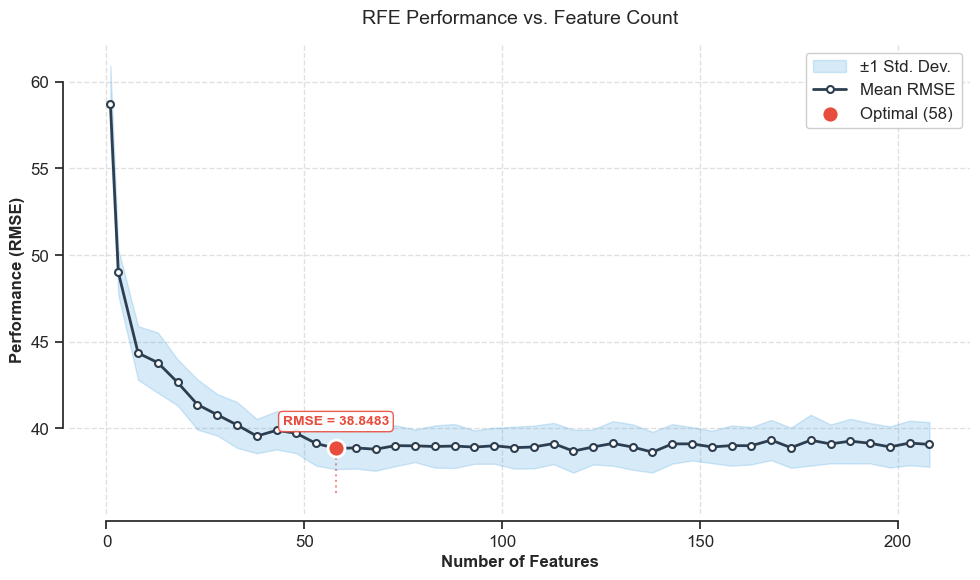

  Optimal Feature Set: 58 features
  Best RMSE: 38.8483


In [23]:
df_Ro5_X_scaled, df_Ro5_X_variance, RFE_results_Ro5_1, df_Ro5_X_final = feature_engineering_workflow('Ro5')

✓ Scaler saved to: ../data_curation/processed_data/scaler_bRo5.pkl
✓ Standardization complete. Shape: (183, 217)
Original features: 217
Removed features: 20
Remaining features: 197


RFE Feature Selection:   2%|▎         | 1/40 iteration

Iteration 0/40 | Features: 192 | RMSE: 46.0348 ± 5.5481 | Removed: [RDKit_NumAromaticCarbocycles, RDKit_SMR_VSA2, RDKit_fr_COO2, RDKit_fr_C_O_noCOO, RDKit_fr_imide]


RFE Feature Selection:  28%|██▊       | 11/40 iteration

Iteration 10/40 | Features: 142 | RMSE: 46.9020 ± 5.2868 | Removed: [RDKit_fr_phos_ester, RDKit_fr_pyridine, RDKit_fr_quatN, RDKit_fr_sulfide, RDKit_fr_sulfonamd]


...

Iteration 20/40 | Features: 92 | RMSE: 48.5212 ± 6.1535 | Removed: [RDKit_HeavyAtomMolWt, RDKit_Kappa2, RDKit_NHOHCount, RDKit_NumHDonors, RDKit_SlogP_VSA11]


RFE Feature Selection:  78%|███████▊  | 31/40 iteration

Iteration 30/40 | Features: 42 | RMSE: 47.2508 ± 7.5602 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_BCUT2D_LOGPHI, RDKit_EState_VSA8, RDKit_MaxPartialCharge, RDKit_qed]


RFE Feature Selection: 100%|██████████| 40/40 iteration



Global best RMSE: 46.0285
Threshold (1.0% tolerance): 46.4887

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 132
  Selected RMSE: 46.3578
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_NumRotatableBonds', 'RDKit_TPSA', 'RDKit_VSA_EState6', 'RDKit_MinEStateIndex']


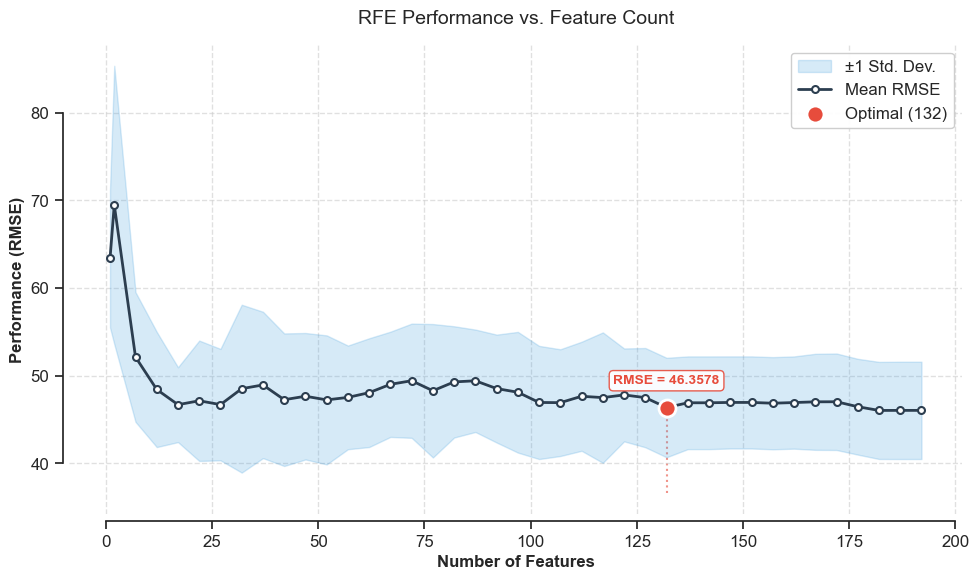

  Optimal Feature Set: 132 features
  Best RMSE: 46.3578


In [24]:
df_H_X_scaled, df_H_X_variance, RFE_results_bRo5_1, df_bRo5_X_final = feature_engineering_workflow('bRo5')

In [25]:
selected_features = hf.combine_features(df_Ro5_X_final, df_bRo5_X_final)

with open(data_prefix + 'selected_feature_list_RDKit.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

with open(data_prefix + 'selected_feature_list_RDKit.pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(selected_features)
print(len(selected_features))

Number of features in Ro5 dataset: 58
Number of features in bRo5 dataset: 132
Number of overlapping features: 46
Overlapping features: {'RDKit_SlogP_VSA8', 'RDKit_PEOE_VSA7', 'RDKit_NumHeteroatoms', 'RDKit_Phi', 'RDKit_RingCount', 'RDKit_SMR_VSA5', 'RDKit_FractionCSP3', 'RDKit_NumHDonors', 'RDKit_fr_Al_OH', 'RDKit_SlogP_VSA12', 'RDKit_MaxPartialCharge', 'RDKit_VSA_EState8', 'RDKit_MaxAbsPartialCharge', 'RDKit_PEOE_VSA14', 'RDKit_HallKierAlpha', 'RDKit_NOCount', 'RDKit_PEOE_VSA6', 'RDKit_fr_ether', 'RDKit_VSA_EState1', 'RDKit_fr_bicyclic', 'RDKit_NumAmideBonds', 'RDKit_BertzCT', 'RDKit_fr_aryl_methyl', 'RDKit_SMR_VSA4', 'RDKit_fr_para_hydroxylation', 'RDKit_SlogP_VSA1', 'RDKit_SMR_VSA9', 'RDKit_SlogP_VSA10', 'RDKit_NumRotatableBonds', 'RDKit_MinPartialCharge', 'RDKit_TPSA', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState9', 'RDKit_MinAbsPartialCharge', 'RDKit_VSA_EState3', 'RDKit_fr_imidazole', 'RDKit_SPS', 'RDKit_fr_NH0', 'RDKit_FpDensityMorgan3', 'RDKit_SMR_VSA3', 'RDKit_VSA_EState2', 'RDKit_Slo

In [26]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features_RDKit_50.parquet')
df_final = hf.dataset_featurization(data_with_features, selected_features, data_prefix + 'final_dataset_RDKit_50')


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is high

✓ RDKit: Added 217 features


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 features...
../data_curation/processed_data/final_dataset_RDKit_50 dataset saved.


In [27]:
df_final = pd.read_parquet(data_prefix + 'final_dataset_RDKit_50.parquet')

df_final_scaled = hf.standardize_data(df_final, data_prefix + 'df_final_scaler_RDKit_50.pkl')


Number of feature columns to standardize: 144
Scaler saved to ../data_curation/processed_data/df_final_scaler_RDKit_50.pkl


In [28]:
import joblib


data_path = "../data_curation/processed_data/final_dataset_RDKit_50.parquet"
scaler_path = "../data_curation/processed_data/df_final_scaler_RDKit_50.pkl"
output_path = "../Ro5/artifacts/final_dataset_RDKit_50_scaled.parquet"


df_final = pd.read_parquet(data_path)


non_feature_cols = ["SMILES", "MP", "Type", "Ro5"] 
feature_cols = [c for c in df_final.columns if c not in non_feature_cols]



scaler = joblib.load(scaler_path)   # Load saved scaler


# Transform features (NO FITTING)

X_scaled = scaler.transform(df_final[feature_cols]) # Transform features (NO FITTING)

# Replace feature columns with scaled values
df_final_scaled = df_final.copy()
df_final_scaled[feature_cols] = X_scaled

# -------------------------
# Save as parquet
# -------------------------
df_final_scaled.to_parquet(output_path, index=False)

print("Scaled dataset saved to:", output_path)


Scaled dataset saved to: ../Ro5/artifacts/final_dataset_RDKit_50_scaled.parquet


In [29]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_50_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_fr_hdrzone,RDKit_PEOE_VSA7,RDKit_EState_VSA2,RDKit_EState_VSA6,RDKit_BalabanJ,RDKit_BCUT2D_LOGPHI,...,RDKit_SMR_VSA10,RDKit_VSA_EState3,RDKit_SlogP_VSA3,RDKit_fr_priamide,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_fr_allylic_oxid,RDKit_NumAliphaticCarbocycles,RDKit_NHOHCount,RDKit_Chi2v
0,CC(OC(=O)C1=C(C(=O)O)[C@@H]2c3c([C@H]1c1c2cccc...,176.35,Train,1,-0.154591,0.514333,0.902852,0.256085,-0.871754,1.634633,...,-0.368426,0.172390,1.088841,-0.164654,0.288195,-0.31017,-0.199503,3.156040,-0.060398,0.798849
1,OC1CCC2(C(C1)CCC1C2CCC2(C1CC=C2)C)C,142.75,Train,1,-0.154591,3.022320,-0.259497,-0.765812,-1.465508,2.116876,...,-1.180776,0.186901,-0.767105,-0.164654,-0.417644,-0.31017,1.991471,4.321435,-0.060398,1.580219
2,S=C(c1ccccc1)c1ccccc1,53.50,Train,1,-0.154591,-0.744243,-0.896031,-0.765812,-0.360971,-0.768181,...,-0.018420,-0.849621,-0.767105,-0.164654,-0.792831,-0.31017,-0.199503,-0.340144,-0.842397,-0.432112
3,O=Cc1c(C)cccc1Cl,37.00,Train,1,-0.154591,-0.369979,-0.896031,-0.318135,1.090341,-0.434934,...,0.036332,-0.795611,-0.767105,-0.164654,-0.708783,-0.31017,-0.199503,-0.340144,-0.842397,-0.802032
4,C=Cn1c2ccccc2c2c1cccc2,63.00,Train,1,-0.154591,-0.693554,-0.896031,-0.765812,0.138840,0.196002,...,0.724848,-0.584253,-0.767105,-0.164654,-0.810418,-0.31017,-0.199503,-0.340144,-0.842397,-0.387503
